In [1]:
# 라이브러리 로딩
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam


# 디바이스 준비
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [2]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    return train_loader, x_val_tensor, y_val_tensor


In [3]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0


    model.train() # 학습 모드로 설정
    for x, y in dataloader: # 배치 단위로 로딩
        x, y = x.to(device), y.to(device) # 디바이스 지정


        # Feed Forward(오차 순전파)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss


        # Backpropagation(오차 역전파)
        loss.backward() # 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
        optimizer.step() # 옵티마이저가 모델의 파라미터를 업데이트
        optimizer.zero_grad() # 옵티마이저의 기울기값 초기화.


    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()


In [4]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정


    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산


    return eval_loss, pred


In [5]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()


In [6]:
path = 'https://bit.ly/irisdata_csv'
data = pd.read_csv(path)
data.head()


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
target = 'Species'
x = data.drop(target, axis = 1)
y = data.loc[:, target]


In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
print(type(y))


<class 'numpy.ndarray'>


In [14]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [15]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3, random_state=20)


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


# 데이터 로더
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)


In [ ]:
print(le.classes_)          # 3개. 출력층의 크기가 됨.
y_orig = le.inverse_transform(y)    

['setosa' 'versicolor' 'virginica']


In [ ]:
n_feature = x.shape[1]      # 입력층 개수. 4개, 컬럼수
n_class = len(le.classes_)  # 출력층 개수. 레이블의 클래스 수


# 모델 구조 설계
model = nn.Sequential(
            nn.Linear(n_feature, n_class),
            ).to(device)


In [18]:
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.1)


In [19]:
epochs = 50
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')


Epoch 1, train loss : 1.058740, val loss : 0.988273
Epoch 2, train loss : 0.898993, val loss : 0.847532
Epoch 3, train loss : 0.727043, val loss : 0.701089
Epoch 4, train loss : 0.627991, val loss : 0.631455
Epoch 5, train loss : 0.571804, val loss : 0.598021
Epoch 6, train loss : 0.533583, val loss : 0.562638
Epoch 7, train loss : 0.474480, val loss : 0.517922
Epoch 8, train loss : 0.448453, val loss : 0.495068
Epoch 9, train loss : 0.408479, val loss : 0.483477
Epoch 10, train loss : 0.379482, val loss : 0.492144
Epoch 11, train loss : 0.369380, val loss : 0.467311
Epoch 12, train loss : 0.357577, val loss : 0.445144
Epoch 13, train loss : 0.335743, val loss : 0.436013
Epoch 14, train loss : 0.332206, val loss : 0.430586
Epoch 15, train loss : 0.322116, val loss : 0.432664
Epoch 16, train loss : 0.294578, val loss : 0.418304
Epoch 17, train loss : 0.313212, val loss : 0.409233
Epoch 18, train loss : 0.291752, val loss : 0.402618
Epoch 19, train loss : 0.289456, val loss : 0.401391
Ep

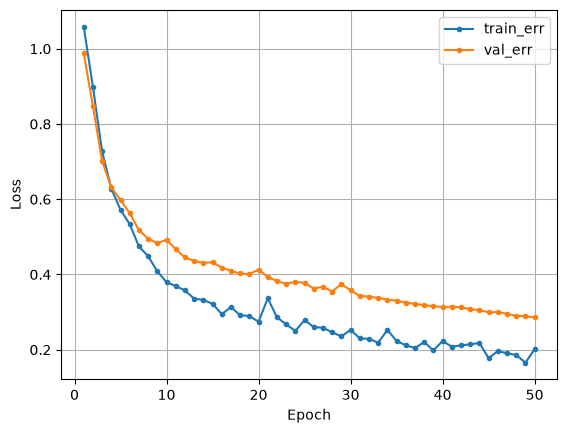

In [20]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [22]:
# 다중 분류 모델링 실습 - MNIST
from torchvision import datasets
from torchvision.transforms import ToTensor


train_dataset = datasets.MNIST( # Train 따로, test 따로.
    root='data',
    train=True,
    download=True,
    transform=ToTensor() )
test_dataset = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor() )


In [23]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [ ]:
train_dataset.data.shape

# 28, 28 : 한 장의 이미지

torch.Size([60000, 28, 28])

In [ ]:
# 이미지 데이터
# 레이블
train_dataset.targets.shape

torch.Size([60000])

In [28]:
train_dataset.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

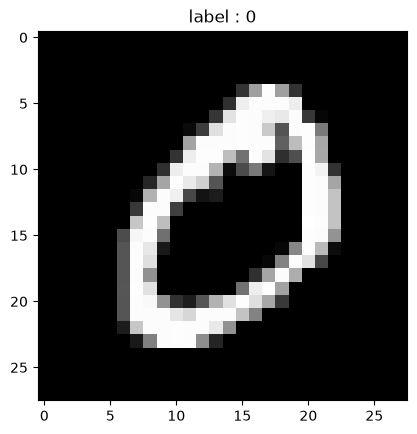

In [55]:
# 한 장의 이미지 출력
n = 1
image, label = train_dataset.data[n], train_dataset.targets[n]
# 이미지 시각화
plt.imshow(image, cmap='gray')
plt.title(f"label : {label}")
plt.show()

In [43]:
batch_size = 64     # 한 번에 이미지 64장 넣어서 학습시키겠다.
train_loader = DataLoader(train_dataset, batch_size=batch_size)

In [ ]:
x_val, x_test = test_dataset.data[:5000], test_dataset.data[5000:]          # 학습할 때(epoch)마다 테스트해야 함(validation), 학습 후 테스트(test)
y_val, y_test = test_dataset.targets[:5000], test_dataset.targets[5000:]
x_val.shape, y_val.shape

(torch.Size([5000, 28, 28]), torch.Size([5000]))

In [46]:
# MinMax 정규화
x_val = x_val / 255
x_test = x_test / 255

In [ ]:
x_val = x_val.view(5000, 1, 28, 28)     # 4차원 변경
x_test = x_test.view(5000, 1, 28, 28)   # 4차원 변경
print(x_val.shape, x_test.shape)

torch.Size([5000, 1, 28, 28]) torch.Size([5000, 1, 28, 28])


In [ ]:
n_feature = 28 * 28     # 입력층
n_class = 10            # 출력층


# 모델 구조 설계
model = nn.Sequential(nn.Flatten(),     # flatten(): 28*28(2차원)을 784(1차원)로 변경. 
    nn.Linear(n_feature, n_class)       # 이미지 한 장 받아서 10개로 분류하겠다.
    ).to(device)                        # 7840+10개 w가 있음.(10은 각각의 절편 w. 7840은 784*10)
                                        # Softmax가 없다..


loss_fn = nn.CrossEntropyLoss()         # 다중 분류라..
optimizer = Adam(model.parameters(), lr=0.001)

In [ ]:
train_dataset.data.shape

torch.Size([60000, 28, 28])

In [51]:
epochs = 10
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')


Epoch 1, train loss : 0.550575, val loss : 0.428107
Epoch 2, train loss : 0.329181, val loss : 0.378609
Epoch 3, train loss : 0.300155, val loss : 0.360303
Epoch 4, train loss : 0.286262, val loss : 0.351196
Epoch 5, train loss : 0.277710, val loss : 0.345971
Epoch 6, train loss : 0.271731, val loss : 0.342696
Epoch 7, train loss : 0.267221, val loss : 0.340521
Epoch 8, train loss : 0.263644, val loss : 0.339025
Epoch 9, train loss : 0.260708, val loss : 0.337978
Epoch 10, train loss : 0.258234, val loss : 0.337244


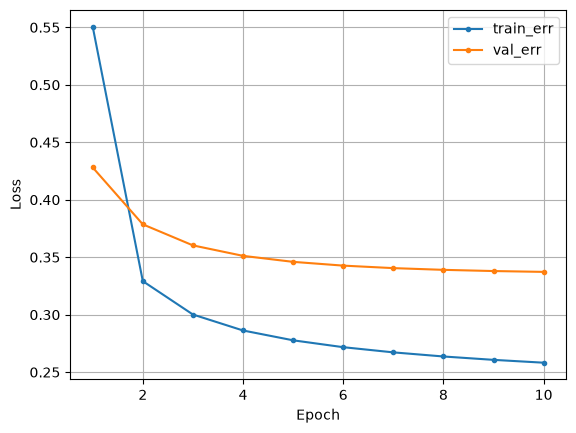

In [52]:
# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)


In [ ]:
# 이미지 1개당 예측값 10개 나옴. 그 중 제일 큰 값의 인덱스가 label     # 5000 X 10 (이미지 5000개)
_, pred = evaluate(x_test, y_test, model, loss_fn, device)  # pred : -inf ~ + inf
pred = nn.functional.softmax(pred, dim=1)
print(pred[:5])

# [1.2560e-03, 7.7897e-06, 8.0371e-04, 6.3364e-01(0.63), 4.1636e-04, 3.5946e-01(0.35),
#          3.0757e-06, 1.0815e-05, 3.7526e-03, 6.5180e-04],
# 3일 확률이 0.63, 5일 확률이 0.35

tensor([[1.2560e-03, 7.7897e-06, 8.0371e-04, 6.3364e-01, 4.1636e-04, 3.5946e-01,
         3.0757e-06, 1.0815e-05, 3.7526e-03, 6.5180e-04],
        [2.8349e-04, 7.7735e-08, 3.2279e-03, 8.3813e-03, 2.7342e-01, 4.2402e-03,
         3.4669e-04, 3.6604e-03, 2.3816e-01, 4.6828e-01],
        [7.0834e-07, 2.9194e-11, 1.3119e-07, 1.5000e-06, 4.9045e-03, 1.2775e-06,
         1.0858e-07, 7.9583e-04, 2.2860e-03, 9.9201e-01],
        [2.5504e-07, 1.1933e-09, 9.5985e-07, 5.2819e-06, 2.9853e-07, 2.9386e-04,
         9.6769e-09, 2.3789e-08, 9.9924e-01, 4.6319e-04],
        [7.6455e-05, 7.8456e-12, 3.7009e-06, 1.0777e-07, 9.9842e-01, 2.5230e-05,
         5.4977e-05, 2.9801e-05, 1.5670e-04, 1.2290e-03]], device='cuda:0')


In [ ]:
pred = np.argmax(pred.cpu().numpy(), axis = 1)      # 최댓값이 들어있는 인덱스 반환
print(pred[:5])

[3 9 9 8 4]


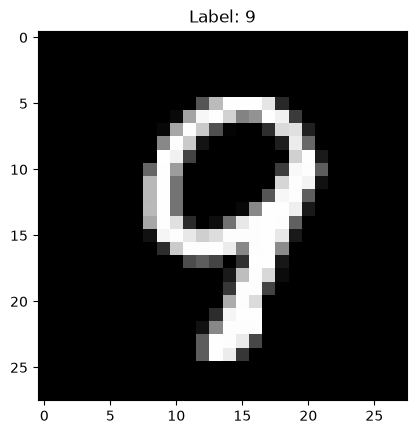

In [ ]:
# x_test
# [3 9 9 8 4]
n = 1
image, label = test_dataset.data[5000+n], test_dataset.targets[5000+n]
plt.imshow(image, cmap='gray')
plt.title(f"Label: {label}")
plt.show()

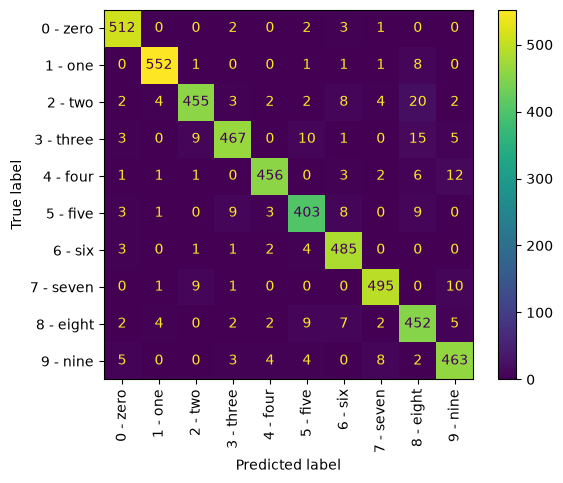

In [66]:
cm = confusion_matrix(y_test.numpy(), pred)
disp = ConfusionMatrixDisplay(cm, display_labels = train_dataset.classes)
disp.plot()
plt.xticks(rotation=90)
plt.show()


In [ ]:
# 은닉층 추가
n_feature = 28 * 28
n_class = 10
# 모델 구조 설계
model = nn.Sequential(nn.Flatten(),         # Linear는 1차원으로 받기 때문에 Flatten()
            nn.Linear(n_feature, 20), nn.ReLU(),
            nn.Linear(20, n_class)
            ).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)


In [68]:
epochs = 10
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val, y_val, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')


Epoch 1, train loss : 0.527804, val loss : 0.385280
Epoch 2, train loss : 0.284552, val loss : 0.336254
Epoch 3, train loss : 0.248838, val loss : 0.309291
Epoch 4, train loss : 0.222855, val loss : 0.282584
Epoch 5, train loss : 0.198883, val loss : 0.258850
Epoch 6, train loss : 0.179921, val loss : 0.241707
Epoch 7, train loss : 0.165508, val loss : 0.228217
Epoch 8, train loss : 0.154147, val loss : 0.217099
Epoch 9, train loss : 0.144811, val loss : 0.209318
Epoch 10, train loss : 0.136917, val loss : 0.203034


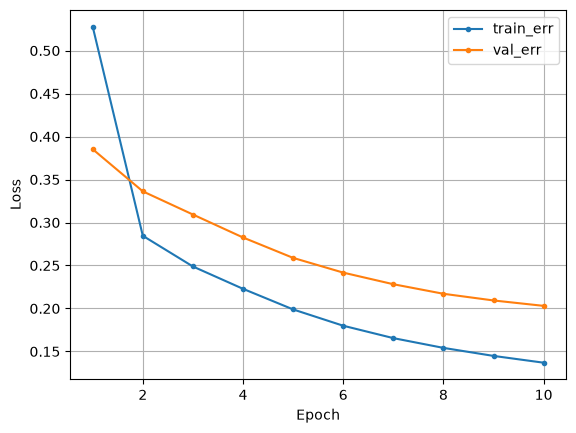

In [69]:
# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)
